# 1. Importando as bibliotecas necessárias 

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [3]:
# MUDAR ESSA VARIÁVEL PARA O CAMINHO PARA O CAMINHO DO DATASET NO SEU COMPUTADOR
caminho_do_dataset = '/home/ptelima/ciencia-de-dados/archive/games.csv'

In [4]:
dataset = pd.read_csv(caminho_do_dataset, sep=',')

# 2. Exploração do dataset

In [5]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 111452 entries, 0 to 111451
Data columns (total 40 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   AppID                       111452 non-null  int64  
 1   Name                        111446 non-null  object 
 2   Release date                111452 non-null  object 
 3   Estimated owners            111452 non-null  object 
 4   Peak CCU                    111452 non-null  int64  
 5   Required age                111452 non-null  int64  
 6   Price                       111452 non-null  float64
 7   Discount                    111452 non-null  int64  
 8   DLC count                   111452 non-null  int64  
 9   About the game              104969 non-null  object 
 10  Supported languages         111452 non-null  object 
 11  Full audio languages        111452 non-null  object 
 12  Reviews                     10624 non-null   object 
 13  Header image  

In [6]:
for coluna in dataset.columns:
	print(coluna)

AppID
Name
Release date
Estimated owners
Peak CCU
Required age
Price
Discount
DLC count
About the game
Supported languages
Full audio languages
Reviews
Header image
Website
Support url
Support email
Windows
Mac
Linux
Metacritic score
Metacritic url
User score
Positive
Negative
Score rank
Achievements
Recommendations
Notes
Average playtime forever
Average playtime two weeks
Median playtime forever
Median playtime two weeks
Developers
Publishers
Categories
Genres
Tags
Screenshots
Movies


# Jogo com Mais recomendações do Dataset

In [7]:
dataset['Recommendations'].argmax() # <- argmax retorna o índice do valor máximo da coluna Recommendations

dataset['Name'].iloc[46158] # <- iloc acessa o elemento da coluna Name pelo índice dele obtido na linha anterior
# insight: CS:GO é o jogo com o maior número de recomendações

# estimativa da quantidade de pessoas que tem esse jogo
dataset['Estimated owners'].iloc[46158] # <- 50000000 - 100000000

dataset['Average playtime forever'].iloc[46158] # <- Maior tempo médio de gameplay de sempre
dataset['Name'].iloc[46158] # <- CS:GO

dataset['Required age'].iloc[46158] # <- 0. Tá certo isso?

dataset['']

KeyError: ''

# Jogos com a maior quantidade de avaliações positivas x negativas:
## Counter Strike: Global Offensive e PUBG: Battlegrounds, respectivamente

In [ ]:
dataset['Positive'].argmax() # retorna a linha que o CS:GO está
dataset['Name'].iloc[46158] # <- já sabemos o resultado dessa linha de acordo com a célula anterior
# insight: CS:GO é o jogo com o maior número de avaliações positivas

dataset['Negative'].argmax() # retorna o a linha que o PUBG está
dataset['Name'].iloc[8885] # -> PUBG: BATTLEGROUNDS
# insight: surpreendentemente, PUBG é o jogo com o maior número de avaliações negativas

# estimativa da quantidade de pessoas que tem esse jogo
dataset['Estimated owners'].iloc[8885] # <- 50000000 - 100000000
# quantidade de pessoas que tem o PUBG

'50000000 - 100000000'

# Jogo com o maior número de DLC's

In [ ]:
filtr_dlc_m_zero = dataset[ dataset['DLC count'] > 0] #filtrando pelos jogos com mais de 0 dlcs
filtr_dlc_m_zero['DLC count'].argmax()
filtr_dlc_m_zero['Name'].iloc[5300] # <- Fantasy Grounds Unity. Nunca ouvi falar desse jogo

'Fantasy Grounds Unity'

In [ ]:
filtro = dataset['Estimated owners']
sns.barplot(data=filtro,orient='y')
plt.xticks(rotation=45)
plt.grid()
plt.show()

KeyboardInterrupt: 

In [ ]:
print(dataset.isnull().sum())

AppID                              0
Name                               6
Release date                       0
Estimated owners                   0
Peak CCU                           0
Required age                       0
Price                              0
Discount                           0
DLC count                          0
About the game                  6483
Supported languages                0
Full audio languages               0
Reviews                       100828
Header image                       0
Website                        64994
Support url                    60693
Support email                  19025
Windows                            0
Mac                                0
Linux                              0
Metacritic score                   0
Metacritic url                107447
User score                         0
Positive                           0
Negative                           0
Score rank                    111408
Achievements                       0
R

In [ ]:
dataset_limpo = dataset.dropna(axis=1)
display(dataset_limpo.dtypes)

AppID                           int64
Release date                   object
Estimated owners               object
Peak CCU                        int64
Required age                    int64
Price                         float64
Discount                        int64
DLC count                       int64
Supported languages            object
Full audio languages           object
Header image                   object
Windows                          bool
Mac                              bool
Linux                            bool
Metacritic score                int64
User score                      int64
Positive                        int64
Negative                        int64
Achievements                    int64
Recommendations                 int64
Average playtime forever        int64
Average playtime two weeks      int64
Median playtime forever         int64
Median playtime two weeks       int64
dtype: object

In [ ]:
print(dataset_limpo['Positive'].head(10))

0      6
1     53
2      0
3      3
4     50
5     87
6     21
7      0
8     76
9    225
Name: Positive, dtype: int64


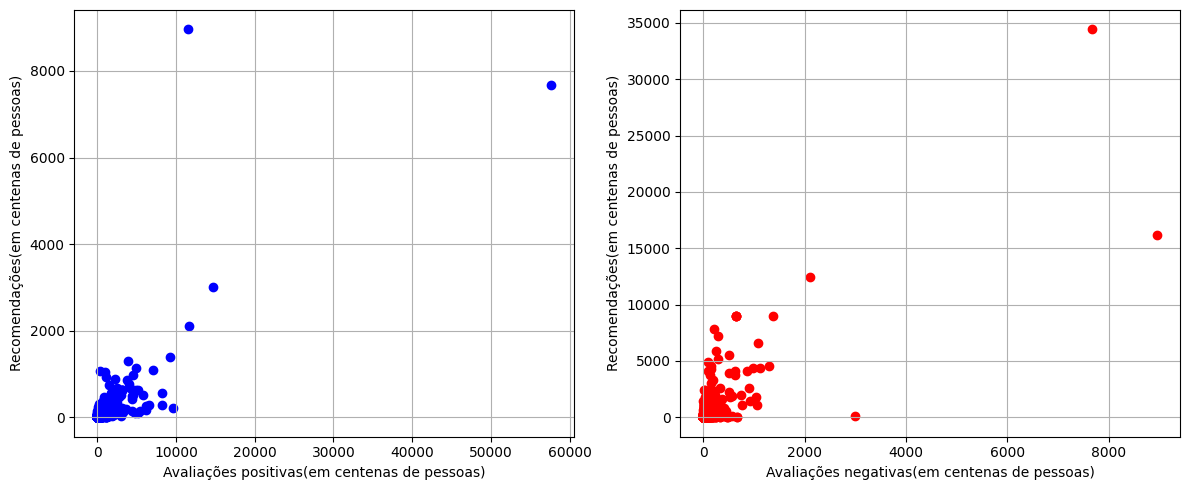

In [ ]:
# 1.Preparando os dados
eixo_positive = dataset_limpo['Positive']/100
eixo_negative = dataset_limpo['Negative']/100
eixo_recomend = dataset_limpo['Recommendations']/100

# 2. Criando o gráfico
plt.figure(figsize=(12,5))

# PRIMEIRO GRÁFICO
plt.subplot(1,2,1)
plt.scatter(eixo_positive, eixo_negative, color='blue')
#plt.title('Avaliações positivas x Recomendações')
plt.xlabel('Avaliações positivas(em centenas de pessoas)')
plt.ylabel('Recomendações(em centenas de pessoas)')
plt.grid(True)
#plt.xticks(rotation=45)

# SEGUNDO GRÁFICO
plt.subplot(1,2,2)
plt.scatter(eixo_negative,eixo_recomend, color='red')
plt.xlabel('Avaliações negativas(em centenas de pessoas)')
plt.ylabel('Recomendações(em centenas de pessoas)')
plt.grid(True)
#plt.xticks(rotation=45)

# 3. Exibindo o gráfico
plt.tight_layout()
plt.show()

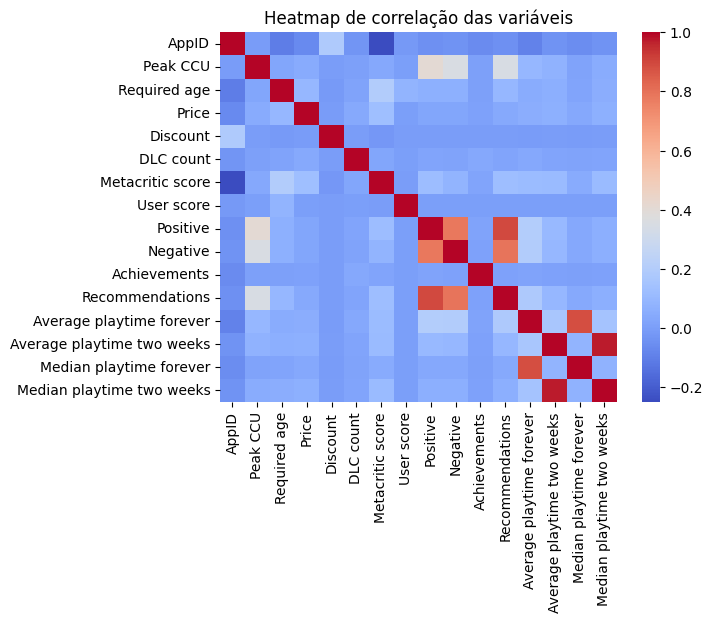

In [ ]:
dataset_numerico = dataset_limpo.copy()
dataset_numerico = dataset_numerico.select_dtypes(include=np.number)
corr_matrix = dataset_numerico.corr()
plt.figure(figsize=(16,12))

sns.heatmap(data=corr_matrix,annot=False, cmap='coolwarm')
plt.title('Heatmap de correlação das variáveis')
plt.show()